<a href="https://colab.research.google.com/github/italobe/desafio-final-backend-dds-t16/blob/master/.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

(total de imagens, dimensão 1, dimensão 2)=(60000, 28, 28)
rotulos=[9 0 0 ... 3 0 5]- São rotulos nas classes 0,1,2,3....,9
total de imagens para teste , dimensão 1, dimensão 2=(10000, 28, 28)


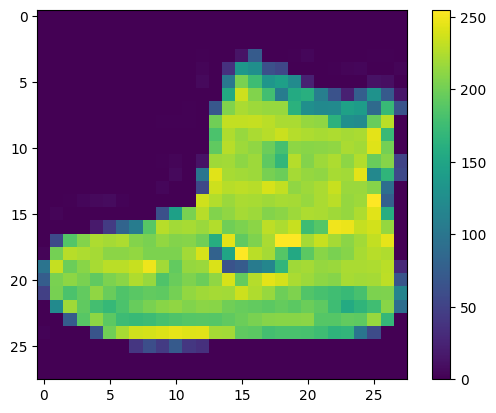

Explicação: exibindo a primeira imagem da base. Os dados numéricos se referem aos Pixels de 0 a 255.


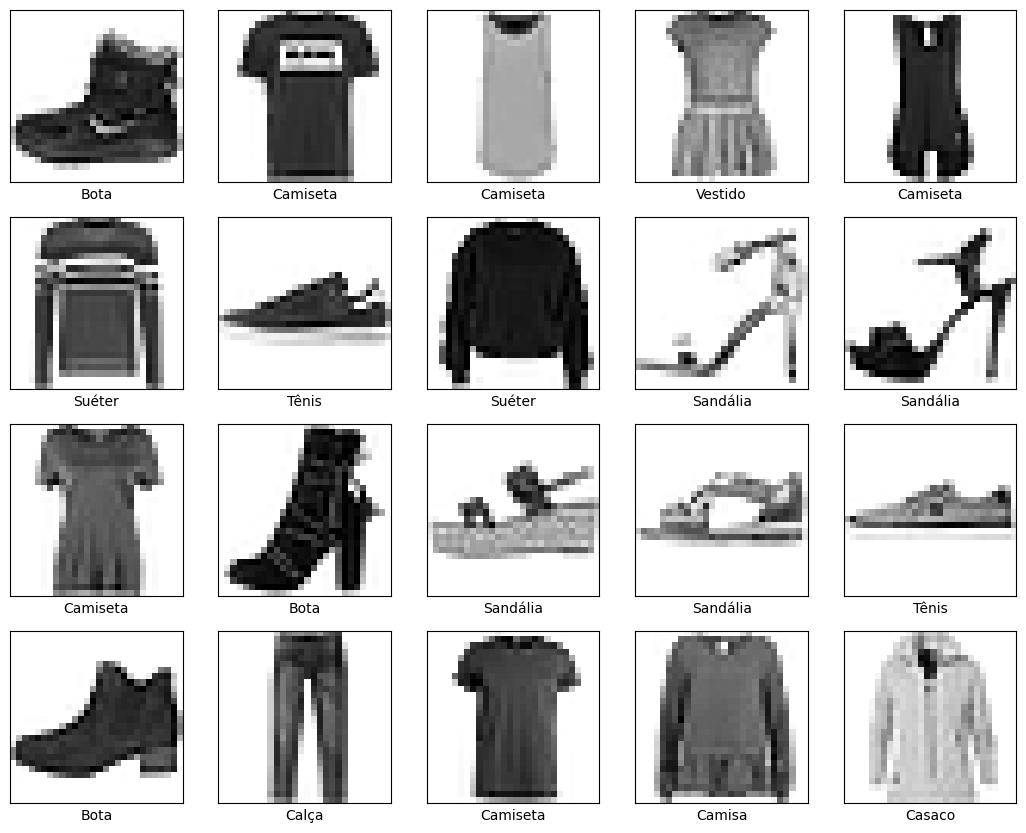

/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.7840 - loss: 0.6176
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8599 - loss: 0.3878
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8772 - loss: 0.3367
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8853 - loss: 0.3118
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8924 - loss: 0.2974
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8812 - loss: 0.3362
Presisão dos testes: 0.8791000247001648
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
[3.2403848e-05 1.0446822e-11 9.9622303e-01 7.9353879e-07 1.2836036e-03
 4.1206114e-09 2.4600644e-03 1.8863127e-16 3.8392942e-09 3.4411903e-14]


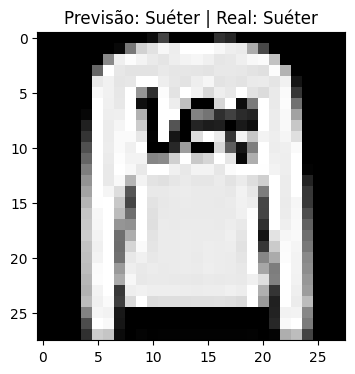

In [19]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

#carregar os dados do mnis

fashion_mnist = keras.datasets.fashion_mnist
(treinamento_imagens, treinamento_rotulos), (teste_imagens, teste_rotulos) = fashion_mnist.load_data()

# definir nomes das classes

nomes_das_classes = ['Camiseta', 'Calça', 'Suéter', 'Vestido', 'Casaco',
                     'Sandália', 'Camisa', 'Tênis', 'Bolsa', 'Bota']

# explorar os dados

print(f'(total de imagens, dimensão 1, dimensão 2)={treinamento_imagens.shape}')
print(f'rotulos={treinamento_rotulos}- São rotulos nas classes 0,1,2,3....,9')
print(f'total de imagens para teste , dimensão 1, dimensão 2={teste_imagens.shape}')

# exibir inicialmente os dados

plt.figure()
plt.imshow(treinamento_imagens[0])
plt.colorbar()
plt.grid(False)
plt.show()

print('Explicação: exibindo a primeira imagem da base. Os dados numéricos se referem aos Pixels de 0 a 255.')

#Reescalar os dados para a escala 0-1

treinamento_imagens = treinamento_imagens / 255.0
teste_imagens = teste_imagens / 255.0

#exibir algumas imagens

plt.figure(figsize=(13,13))
for i in range(20):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(treinamento_imagens[i], cmap=plt.cm.binary)
    plt.xlabel(nomes_das_classes[treinamento_rotulos[i]])
plt.show()

# criar modelo

modelo = keras.Sequential([
    keras.layers.Flatten(input_shape=(28,28)),
    keras.layers.Dense(128, activation=tf.nn.relu),
    keras.layers.Dense(10, activation=tf.nn.softmax)
])

# compilar modelo

modelo.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# treinar modelo

modelo.fit(treinamento_imagens, treinamento_rotulos, epochs=5)

# testa a precisão do modelo

perda_teste, precisao_teste = modelo.evaluate(teste_imagens, teste_rotulos)
print('Presisão dos testes:', precisao_teste)

# realizar predições

item_teste = 1

previsoes = modelo.predict(teste_imagens)
print(previsoes[item_teste])

melhor_classificacao = np.argmax(previsoes[item_teste])

plt.figure(figsize=(14,4))
plt.imshow(teste_imagens[item_teste], cmap=plt.cm.gray)
plt.title(f'Previsão: {nomes_das_classes[melhor_classificacao]} | Real: {nomes_das_classes[teste_rotulos[item_teste]]}')
plt.show()